# XGBoost - Car Preference Learning

**Aleksander Hański 160315 and Michał Żurawski 160252**

We use the preprocessed Cars 2025 dataset (177 alternatives, 4 monotonic criteria)
to train an XGBoost classifier with monotone constraints that models Michał's preferences.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.inspection import PartialDependenceDisplay
import shutil, importlib.util
from xgboost import plot_tree
_HAS_GRAPHVIZ = (
    shutil.which("dot") is not None
    and importlib.util.find_spec("graphviz") is not None
)

## 1. Load data

In [2]:
df_raw = pd.read_csv("dataset/dataset_preprocessed_continuous.csv")
print(df_raw.shape)
df_raw.head()

(177, 6)


,Company Names,Cars Names,HorsePower,Cars Prices,Seats,Total Speed
0,TOYOTA,TOYOTA LAND CRUISER,381,85000.0,7,220
1,TOYOTA,TOYOTA SEQUOIA,381,50000.0,7,200
2,NISSAN,PATHFINDER,284,35000.0,7,225
3,AUDI,Q7,335,60000.0,7,250
4,VOLVO,XC90,247,60000.0,7,200


## 2. Criteria

| Criterion     | Type | Unit   | Constraint |
|---------------|------|--------|------------|
| HorsePower    | gain | hp     | +1         |
| Cars Prices   | cost | USD    | -1         |
| Seats         | gain | count  | +1         |
| Total Speed   | gain | km/h   | +1         |

Raw continuous values are used directly.  No ordinal encoding needed.
The monotone constraint for `Cars Prices` is **-1** (higher price -> less preferred).

In [3]:
df = df_raw.copy()

FEATURE_NAMES = ['HorsePower', 'Cars Prices', 'Seats', 'Total Speed']

# Actual value ranges - used to bound the flip search
FEATURE_RANGES = {f: (df[f].min(), df[f].max()) for f in FEATURE_NAMES}
print("Feature ranges:")
for f, (lo, hi) in FEATURE_RANGES.items():
    print(f"  {f}: [{lo}, {hi}]")

print(df[FEATURE_NAMES].describe())

Feature ranges:
  HorsePower: [85, 670]
  Cars Prices: [15000.0, 105000.0]
  Seats: [7, 12]
  Total Speed: [125, 250]
       HorsePower    Cars Prices       Seats  Total Speed
count  177.000000     177.000000  177.000000   177.000000
mean   274.293785   50011.158192    7.203390   195.305085
std    103.608220   19888.370644    0.536603    22.711822
min     85.000000   15000.000000    7.000000   125.000000
25%    181.000000   35000.000000    7.000000   180.000000
50%    290.000000   47500.000000    7.000000   200.000000
75%    355.000000   60000.000000    7.000000   210.000000
max    670.000000  105000.000000   12.000000   250.000000


## 3. Define target class

The dataset has no pre-defined decision classes, so we construct a utility score with
equal weights on all four criteria.  Before summing, each criterion is normalised to
[0, 1]; `Cars Prices` is **inverted** so cheaper -> higher utility.
Alternatives are ranked by utility and split 50/50 into class 1 (preferred) / class 0.

In [4]:
def normalise(s):
    return (s - s.min()) / (s.max() - s.min())

df['utility'] = (
    normalise(df['HorsePower']) +
    normalise(df['Cars Prices'].max() - df['Cars Prices']) +   # inverted: cheaper = better
    normalise(df['Seats']) +
    normalise(df['Total Speed'])
)
# Rank-based split -> exactly 50/50 balance (ties broken by first-occurrence order)
n = len(df)
df['class'] = (df['utility'].rank(method='first', ascending=True) > n // 2).astype(int)

print("Class distribution:")
print(df['class'].value_counts().rename({0: 'class 0 (not preferred)', 1: 'class 1 (preferred)'}))

Class distribution:
class
class 1 (preferred)        89
class 0 (not preferred)    88
Name: count, dtype: int64


In [5]:
X = df[FEATURE_NAMES].astype(float).copy()
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)
print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

Train size: 141  |  Test size: 36


## 4. Train XGBoost with monotone constraints

Features are in the order `[HorsePower, Cars Prices, Seats, Total Speed]`.
`Cars Prices` is a **cost** criterion, so its constraint is **-1** (higher price -> lower preference).
A single tree (`n_estimators=1`) keeps the model fully interpretable.

In [6]:
CRITERIA_NR = len(FEATURE_NAMES)

params = {
    "max_depth": CRITERIA_NR * 2,
    "eta": 0.1,
    "nthread": 2,
    "seed": 0,
    "eval_metric": "logloss",
    "base_score": 0.5,
    "monotone_constraints": "(1,-1,1,1)",   # HP, Price(cost), Seats, Speed
    "n_estimators": 1,
}

model = xgb.XGBClassifier(**params)
model.fit(X_train, y_train)
print("Monotone constraints:", params["monotone_constraints"])

Monotone constraints: (1,-1,1,1)


## 5. Metrics: Accuracy, F1, AUC

In [7]:
for split_name, X_s, y_s in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
    y_pred = model.predict(X_s)
    y_prob = model.predict_proba(X_s)[:, 1]
    acc = accuracy_score(y_s, y_pred)
    f1  = f1_score(y_s, y_pred)
    auc = roc_auc_score(y_s, y_prob)
    print(f"{split_name:5s} | Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")

Train | Accuracy=0.8085  F1=0.7970  AUC=0.9119
Test  | Accuracy=0.9167  F1=0.9143  AUC=0.9552


## 6. Tree visualisation

In [8]:
if _HAS_GRAPHVIZ:
    fig, ax = plt.subplots(figsize=(18, 10))
    plot_tree(model, ax=ax, num_trees=0, feature_names=FEATURE_NAMES)
    plt.title("XGBoost Decision Tree (tree 0)")
    plt.tight_layout()
    plt.show()
else:
    # Fallback: print the tree structure as text
    dump = model.get_booster().get_dump(fmap="", with_stats=True)[0]
    # Replace internal feature names f0/f1/... with readable names
    for i, name in enumerate(FEATURE_NAMES):
        dump = dump.replace(f"f{i}", name)
    print("XGBoost tree structure (text dump):\n")
    print(dump)

XGBoost tree structure (text dump):

0:[Total Speed<195] yes=1,no=2,missing=2,gain=39.8019028,cover=35.25
	1:[Seats<8] yes=3,no=4,missing=4,gain=15.9643021,cover=17
		3:leaf=-0.154098362,cover=14.25
		4:leaf=-0.00212842831,cover=2.75
	2:[Cars Prices<82000] yes=5,no=6,missing=6,gain=9.68481064,cover=18.25
		5:[HorsePower<250] yes=7,no=8,missing=8,gain=7.23482895,cover=15.5
			7:[Total Speed<205] yes=9,no=10,missing=10,gain=0.0356152058,cover=4
				9:leaf=0.065602459,cover=2.75
				10:leaf=0.111111119,cover=1.25
			8:leaf=0.175999999,cover=11.5
		6:leaf=-0.00212842831,cover=2.75



## 7. Feature importance (gain-weighted)

**Gain** measures the average improvement in the loss function brought by each feature
across all splits - a higher gain means that criterion is more decisive.

In [9]:
booster = model.get_booster()
# feature names already match FEATURE_NAMES since X was trained with those columns

print("Split frequency (F-score):")
print(booster.get_fscore())

print("\nGain-weighted importance:")
gain_scores = booster.get_score(importance_type="gain")
print(gain_scores)

Split frequency (F-score):
{'HorsePower': 1.0, 'Cars Prices': 1.0, 'Seats': 1.0, 'Total Speed': 2.0}

Gain-weighted importance:
{'HorsePower': 7.234828948974609, 'Cars Prices': 9.684810638427734, 'Seats': 15.964302062988281, 'Total Speed': 19.918758392333984}


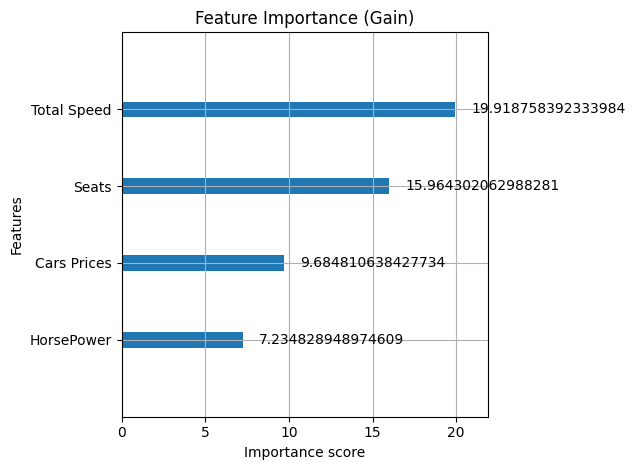

In [10]:
xgb.plot_importance(booster, importance_type="gain", title="Feature Importance (Gain)")
plt.tight_layout()
plt.show()

## 8. Partial Dependence Plots (PDP)

PDPs show the **marginal effect** of each criterion on the predicted probability of being
in class 1.  The monotone constraint guarantees that each single-criterion curve is
non-decreasing (higher criterion value -> higher preference probability).

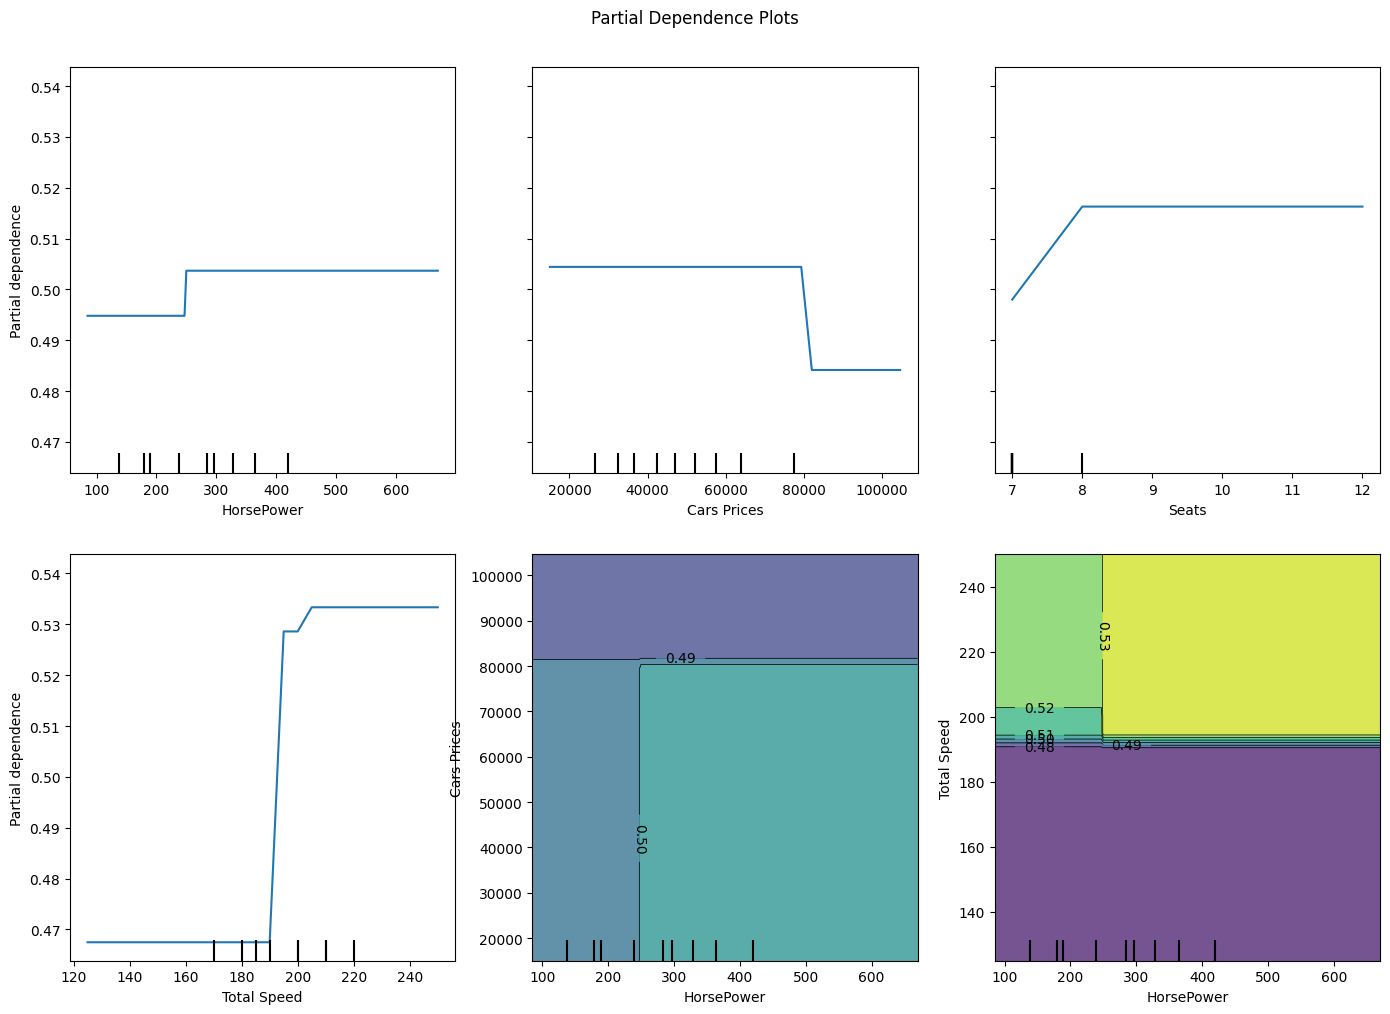

In [11]:
features_pdp = [0, 1, 2, 3, (0, 1), (0, 3)]
fig, ax = plt.subplots(figsize=(14, 10))
PartialDependenceDisplay.from_estimator(
    model, X_train, features_pdp, feature_names=FEATURE_NAMES, ax=ax
)
plt.suptitle("Partial Dependence Plots", y=1.01)
plt.tight_layout()
plt.show()

## 9. Individual Conditional Expectation (ICE) plots

ICE plots show the predicted probability for each individual alternative as one criterion
is varied.  They reveal heterogeneity that PDP averages out.

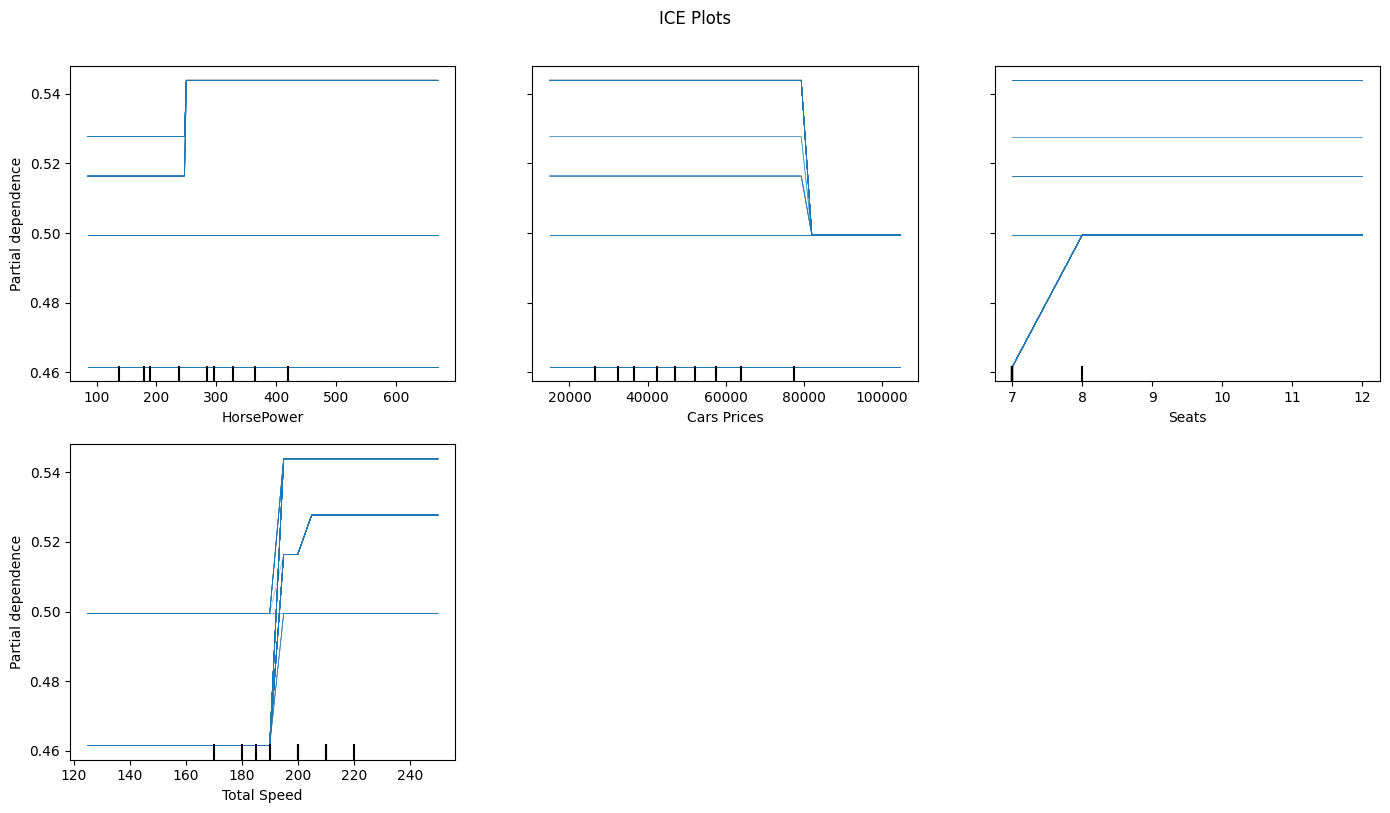

In [12]:
fig, ax = plt.subplots(figsize=(14, 8))
PartialDependenceDisplay.from_estimator(
    model, X_train, [0, 1, 2, 3], feature_names=FEATURE_NAMES, ax=ax, kind="individual"
)
plt.suptitle("ICE Plots", y=1.01)
plt.tight_layout()
plt.show()

## 9b. Permutation Feature Importance

Gain-weighted importance measures how much each feature's splits improved the
training loss; **permutation importance** instead measures how much the test
AUC drops when a feature is shuffled.  It is model-agnostic and complements
the gain view.  We import the shared helper so all three models report the
same metric.

Permutation importance (AUC drop):
  Total Speed     +0.3072 ± 0.0425
  Seats           +0.0620 ± 0.0099
  Cars Prices     +0.0567 ± 0.0060
  HorsePower      +0.0320 ± 0.0091


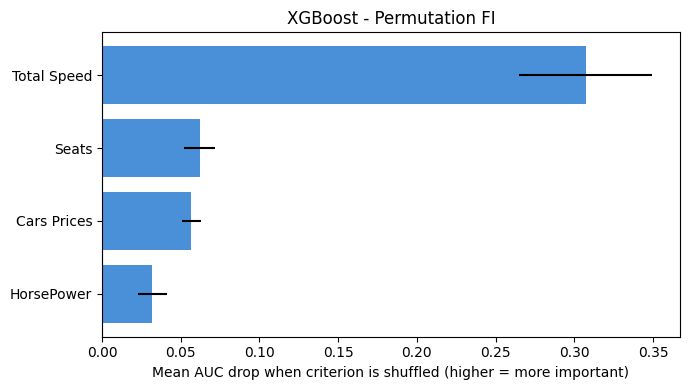

In [13]:
from common_cars import permutation_feature_importance, plot_permutation_importance

def _xgb_predict_proba(X_df):
    return model.predict_proba(X_df)[:, 1]

pfi = permutation_feature_importance(_xgb_predict_proba, X_train, y_train,
                                     feature_names=FEATURE_NAMES, n_repeats=30)
print("Permutation importance (AUC drop):")
for f, (m, s) in sorted(pfi.items(), key=lambda kv: -kv[1][0]):
    print(f"  {f:14s}  {m:+.4f} ± {s:.4f}")
plot_permutation_importance(pfi, title="XGBoost - Permutation FI")

## 10. Select 3 alternatives for deep explanation

We pick one clearly **preferred**, one **borderline**, and one clearly **not preferred**
alternative to examine in detail.

In [14]:
df_pred = df.copy()
df_pred['pred']      = model.predict(X)
df_pred['pred_prob'] = model.predict_proba(X)[:, 1]

def get_name(idx):
    row = df_raw.loc[idx]
    return f"{row['Company Names']} {row['Cars Names']}"

# Select by rank - robust to narrow probability ranges from a single tree
high_idx = df_pred['pred_prob'].idxmax()
low_idx  = df_pred['pred_prob'].idxmin()
# Borderline: closest pred_prob to the median predicted probability
median_prob = df_pred['pred_prob'].median()
mid_idx  = (df_pred['pred_prob'] - median_prob).abs().idxmin()

selected = [high_idx, mid_idx, low_idx]
labels   = ['Preferred', 'Borderline', 'Not preferred']

print("Selected alternatives:")
for idx, lbl in zip(selected, labels):
    row = df_pred.loc[idx]
    print(f"  [{lbl}] {get_name(idx)}")
    print(f"    Criteria: HP={row['HorsePower']:.0f} hp, Price=${row['Cars Prices']:.0f}, "
          f"Seats={row['Seats']:.0f}, Speed={row['Total Speed']:.0f} km/h")
    print(f"    Utility={row['utility']}  Pred prob={row['pred_prob']:.4f}  Class={int(row['pred'])}")

Selected alternatives:
  [Preferred] TOYOTA TOYOTA SEQUOIA
    Criteria: HP=381 hp, Price=$50000, Seats=7, Speed=200 km/h
    Utility=1.7170940170940172  Pred prob=0.5439  Class=1
  [Borderline] TOYOTA TOYOTA LAND CRUISER
    Criteria: HP=381 hp, Price=$85000, Seats=7, Speed=220 km/h
    Utility=1.488205128205128  Pred prob=0.4995  Class=0
  [Not preferred] TOYOTA SIENNA
    Criteria: HP=245 hp, Price=$44150, Seats=7, Speed=190 km/h
    Utility=1.4696153846153845  Pred prob=0.4616  Class=0


## 11. SHAP explanations

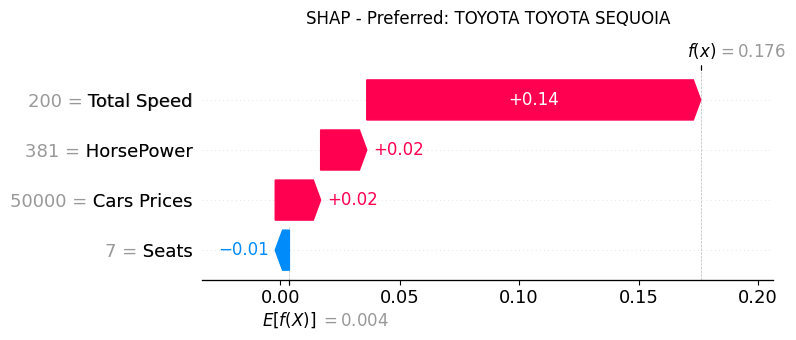

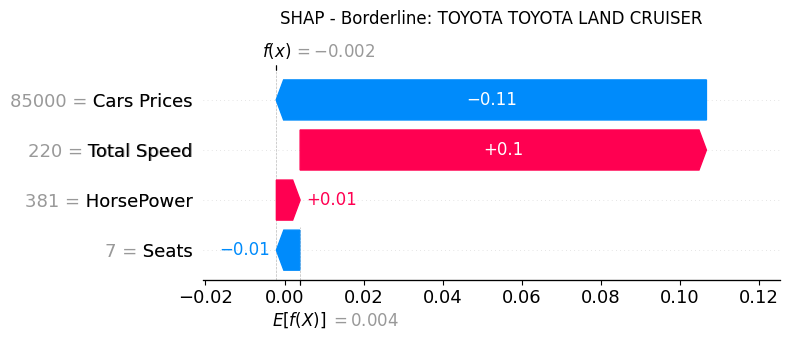

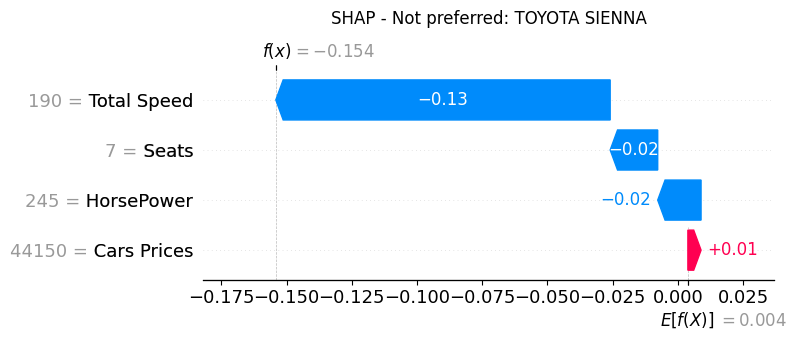

In [15]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

for idx, lbl in zip(selected, labels):
    name = get_name(idx)
    explanation = shap.Explanation(
        values        = shap_values[idx],
        base_values   = explainer.expected_value,
        data          = X.loc[idx].values,
        feature_names = FEATURE_NAMES,
    )
    shap.plots.waterfall(explanation, show=False)
    plt.title(f"SHAP - {lbl}: {name}", pad=12)
    plt.tight_layout()
    plt.show()

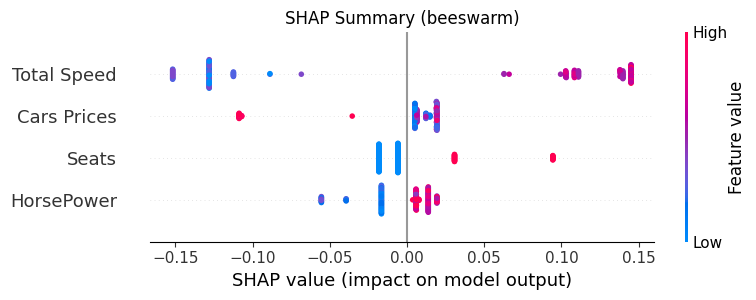

In [16]:
# Summary beeswarm for the full dataset
shap.summary_plot(shap_values, X, feature_names=FEATURE_NAMES, show=False)
plt.title("SHAP Summary (beeswarm)")
plt.tight_layout()
plt.show()

## 12. Minimum single-criterion change to flip class (analytical)

With continuous features the decision boundaries are the **split thresholds** stored in
the tree.  For each criterion we read all thresholds from the tree dump, then find the
closest threshold crossing (value just above or just below) that changes the predicted
class.  The required delta is read directly from the model parameters - no sampling.

In [17]:
def get_tree_thresholds(model, feature_names):
    """Parse split thresholds per feature from the XGBoost text dump."""
    dump = model.get_booster().get_dump()[0]
    thresholds = {f: [] for f in feature_names}
    for line in dump.split('\n'):
        for f in feature_names:
            tag = f'[{f}<'
            if tag in line:
                thresh = float(line.split(tag)[1].split(']')[0])
                thresholds[f].append(thresh)
    return thresholds


def find_min_flip(model, row, feature_names, feature_ranges):
    """Return the minimum-delta single-criterion change that flips the predicted class.

    Uses tree split thresholds directly (analytical) - tries values just above and just
    below each threshold and picks the smallest absolute change that flips the class.
    """
    X_row = pd.DataFrame([row[feature_names]])
    current_pred = int(model.predict(X_row)[0])
    thresholds = get_tree_thresholds(model, feature_names)
    results = []

    for feat in feature_names:
        orig = float(row[feat])
        lo, hi = feature_ranges[feat]
        feat_thresholds = sorted(set(thresholds.get(feat, [])))

        best_for_feat = None
        for thresh in feat_thresholds:
            for new_val in [thresh + 1e-3, thresh - 1e-3]:
                if new_val < lo or new_val > hi or abs(new_val - orig) < 1e-9:
                    continue
                test = row[feature_names].copy()
                test[feat] = new_val
                new_pred = int(model.predict(pd.DataFrame([test]))[0])
                if new_pred != current_pred:
                    delta = new_val - orig
                    if best_for_feat is None or abs(delta) < abs(best_for_feat['delta']):
                        best_for_feat = {
                            'criterion':  feat,
                            'threshold':  thresh,
                            'delta':      delta,
                            'new_val':    new_val,
                            'new_pred':   new_pred,
                        }
        if best_for_feat:
            results.append(best_for_feat)

    return results


print("=" * 60)
for idx, lbl in zip(selected, labels):
    row = df_pred.loc[idx]
    name = get_name(idx)
    print(f"\n[{lbl}] {name}")
    print(f"  Current class: {int(row['pred'])}  "
          f"HP={row['HorsePower']:.0f} hp, Price=${row['Cars Prices']:.0f}, "
          f"Seats={row['Seats']:.0f}, Speed={row['Total Speed']:.0f} km/h")

    flips = find_min_flip(model, row, FEATURE_NAMES, FEATURE_RANGES)
    if flips:
        for f in flips:
            print(f"  -> Change '{f['criterion']}' by {f['delta']:+.1f}"
                  f" (cross tree threshold {f['threshold']:.1f})"
                  f" -> predicted class flips to {f['new_pred']}")
    else:
        print("  -> No single-criterion change can flip the class")


[Preferred] TOYOTA TOYOTA SEQUOIA
  Current class: 1  HP=381 hp, Price=$50000, Seats=7, Speed=200 km/h
  -> Change 'Cars Prices' by +32000.0 (cross tree threshold 82000.0) -> predicted class flips to 0
  -> Change 'Total Speed' by -5.0 (cross tree threshold 195.0) -> predicted class flips to 0

[Borderline] TOYOTA TOYOTA LAND CRUISER
  Current class: 0  HP=381 hp, Price=$85000, Seats=7, Speed=220 km/h
  -> No single-criterion change can flip the class

[Not preferred] TOYOTA SIENNA
  Current class: 0  HP=245 hp, Price=$44150, Seats=7, Speed=190 km/h
  -> Change 'Total Speed' by +5.0 (cross tree threshold 195.0) -> predicted class flips to 1


## 13. Space sampling verification

We apply the minimum change found analytically and confirm the class flip.

In [18]:
print("=" * 60)
for idx, lbl in zip(selected, labels):
    row = df_pred.loc[idx]
    name = get_name(idx)
    orig_pred = int(row['pred'])
    print(f"\n[{lbl}] {name}  (original class={orig_pred})")

    flips = find_min_flip(model, row, FEATURE_NAMES, FEATURE_RANGES)
    if not flips:
        print("  No flip possible - nothing to verify.")
        continue

    best = min(flips, key=lambda x: abs(x['delta']))
    test_row = row[FEATURE_NAMES].copy()
    test_row[best['criterion']] = best['new_val']
    sampled_pred = int(model.predict(pd.DataFrame([test_row]))[0])
    sampled_prob = model.predict_proba(pd.DataFrame([test_row]))[0, 1]

    agree = "✓ AGREE" if sampled_pred != orig_pred else "✗ DISAGREE"
    print(f"  Analytical:  '{best['criterion']}' -> {best['new_val']:.1f}"
          f"  (Δ={best['delta']:+.1f}, crosses threshold {best['threshold']:.1f})"
          f"  -> class {best['new_pred']}")
    print(f"  Sampling:    predicted class={sampled_pred}  prob={sampled_prob:.4f}  {agree}")


[Preferred] TOYOTA TOYOTA SEQUOIA  (original class=1)
  Analytical:  'Total Speed' -> 195.0  (Δ=-5.0, crosses threshold 195.0)  -> class 0
  Sampling:    predicted class=0  prob=0.4616  ✓ AGREE

[Borderline] TOYOTA TOYOTA LAND CRUISER  (original class=0)
  No flip possible - nothing to verify.

[Not preferred] TOYOTA SIENNA  (original class=0)
  Analytical:  'Total Speed' -> 195.0  (Δ=+5.0, crosses threshold 195.0)  -> class 1
  Sampling:    predicted class=1  prob=0.5164  ✓ AGREE


## 14. Model interpretation summary

* **Criterion influence**: The gain-weighted feature importance and SHAP summary reveal
  which criteria most frequently and strongly discriminate preferred from not-preferred cars.

* **Monotonicity**: By construction (monotone_constraints = +1 for all), the model is
  guaranteed to never decrease the preference probability when any criterion improves.
  The PDP curves confirm this visually.

* **Thresholds / indifference zones**: Flat regions in the PDP curves indicate ordinal
  levels where an additional step on that criterion makes no difference to the prediction
  - i.e., indifference ranges in the model's learned preference structure.

* **Criterion nature**: HorsePower, Seats and Total Speed are gain criteria (+1 constraint).
  Cars Prices is a cost criterion (−1 constraint): the tree splits enforce that higher
  price can only decrease the preference probability.

* **Interactions**: The 2-D PDP panels (Section 8) show whether the effect of one
  criterion depends on the level of another (interaction effects).